<a href="https://colab.research.google.com/github/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/blob/main/Notebooks/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_(4052025001857).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Análise descritiva de ocorrências criminais no país entre 2015 e 2022.

**Nome:** Marcelo Alexandre Machado Silvestre

**Matrícula:** 4052025001857

**Datasets:** [Ocorrências Criminais SINESP](https://dados.gov.br/dados/conjuntos-dados/sistema-nacional-de-estatisticas-de-seguranca-publica) e [População IBGE](https://ftp.ibge.gov.br/Projecao_da_Populacao/Projecao_da_Populacao_2018/projecoes_2018_populacao_2010_2060_20200406.xls)



#1- Definição do problema
A criminalidade no Brasil apresenta diferenças relevantes entre estados, tipos de crime e períodos do tempo. Uma análise baseada apenas em valores absolutos pode induzir a conclusões equivocadas, já que estados com maior população tendem a registrar maior número absoluto de ocorrências.

Diante disso, este MVP busca analisar o comportamento da criminalidade no Brasil entre 2015 e 2022, integrando dados de ocorrências criminais e dados populacionais para construir indicadores proporcionais e extrair padrões temporais, regionais e comparativos.

O foco do trabalho está na análise exploratória e no pré-processamento, com a criação de variáveis derivadas que melhorem a interpretação dos dados e possibilitem análises mais robustas.


## 1.1 - Hipóteses:

As hipóteses consideradas neste MVP são as seguintes:

1. Estados mais populosos não necessariamente apresentam as maiores taxas de criminalidade.
2. A padronização por população altera significativamente a interpretação dos resultados.
3. Existem diferenças temporais relevantes na evolução dos crimes.
4. Há diferenças regionais importantes nos padrões de criminalidade.
5. Alguns tipos de crime apresentam maior volatilidade que outros.

## 1.2 - Classificação:

Este trabalho se caracteriza principalmente como um problema de análise exploratória de dados, com abordagem não supervisionada, pois o objetivo principal é compreender padrões, distribuições e relações entre variáveis.

Além disso, o trabalho inclui uma etapa de engenharia de atributos, em que será criada uma variável categórica chamada TENDENCIA, construída a partir da variação da taxa de criminalidade ao longo do tempo. Essa variável poderá servir como target em estudos futuros de classificação.

#2 - Seleção de Dados:

As bases de dados para o projeto foram extraídas da fonte Dados Abertos do Governo Federal, SINESP e da fonte Dados Populacionais fornecidos pelo IBGE. Os dados SINESP correpondem a ocorrências de tipos criminais com maiores relevâncias no Brasil, classificados pelas Uidades da Federação - UF e os dados populacionais, à projeção da população mensal, por UF, fornecida pelo IBGE.



##2.1 - Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##2.2- Carga das bases de dados:

In [ ]:
#importação e armazenamento da base de dados criminais
df_criminal = pd.read_excel('https://raw.githubusercontent.com/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/main/Arquivos/indicadoressegurancapublicauf%20(1).xlsx')
#exibição das três primeiras linhas do dataframe
df_criminal.head(3)


,UF,Tipo Crime,Ano,Mês,Ocorrências
0,Acre,Estupro,2022,janeiro,31
1,Acre,Furto de veículo,2022,janeiro,50
2,Acre,Homicídio doloso,2022,janeiro,10


In [ ]:
#importação da base de dados popucionais do IBGE (2010-2060)
df_pop = pd.read_excel('https://raw.githubusercontent.com/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/main/Arquivos/IBGE_populacao__2010_2060.xlsx')
#seleção e visualização do intervalo de dados a ser utilizado da base populacional
df_base_pop = df_pop.iloc[:,[0]+list(range(6,14))]
df_base_pop.head(3)

,UF,2015,2016,2017,2018,2019,2020,2021,2022
0,Acre,831665,844137,856457,869265,881935,894470,906876,919145
1,Alagoas,3279222,3293629,3307532,3322379,3336911,3351092,3364895,3378277
2,Amapá,779416,796419,813084,829494,845731,861773,877613,893253


#3 - Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA)

##3.1 -  Total e Tipo das Instâncias

O dataset df_base_criminal possui 23020 instâncias (observações). Possui 5 atributos, sendo 3 categóricos (UF, Tipo Crime e Mês e dois, numéricos (Ano e Ocorrências).

In [ ]:
print(f"Total de instâncias: {len(df_criminal)}")
print("Tipos de dados por coluna:")
print()
print(df_criminal.info())

Total de instâncias: 23020
Tipos de dados por coluna:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23020 entries, 0 to 23019
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   UF           23020 non-null  object
 1   Tipo Crime   23020 non-null  object
 2   Ano          23020 non-null  int64 
 3   Mês          23020 non-null  object
 4   Ocorrências  23020 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 899.3+ KB
None


##3.2 - Visualização da quantidade total absoluta de ocorrências dos tipos criminais, ordenados em ordem descrescente.

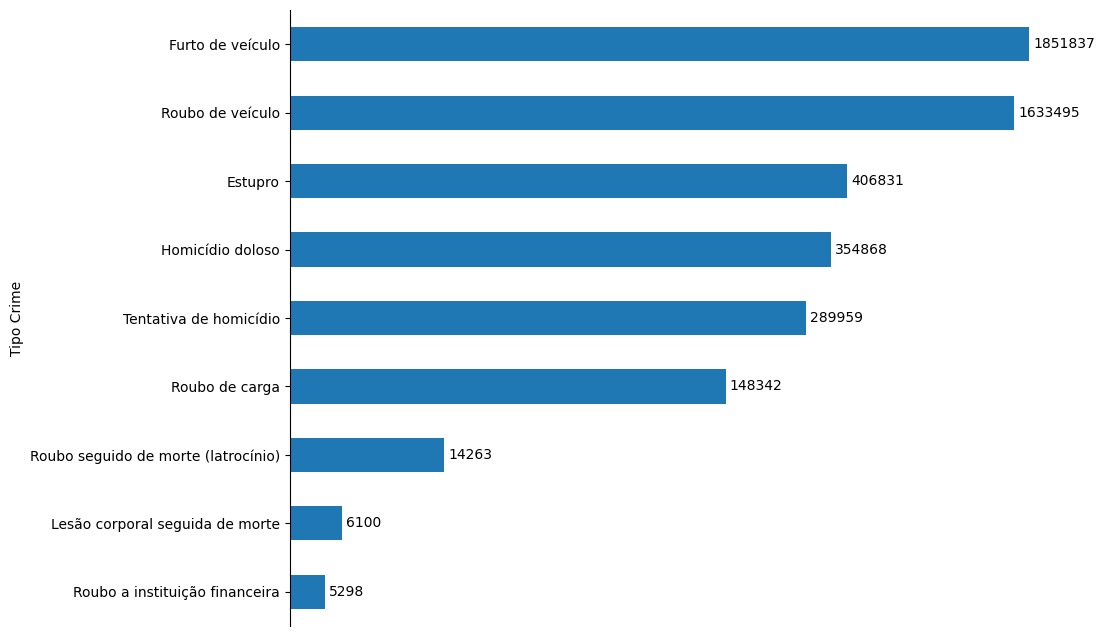

In [ ]:
df_crimes = df_criminal.groupby('Tipo Crime')['Ocorrências'].sum().sort_values(ascending=True)
ax = df_crimes.plot(kind='barh', figsize=(10,8))
ax.set_xscale('log')
ax.bar_label(ax.containers[0],padding=3, fmt = '%.0f')
ax.xaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.show()

##3.3 - Alteração do formato do dataframe df_base de wide para long.

In [ ]:
#alteração do formato do dataframe de wide para long
base_pop_long = pd.melt(df_base_pop,id_vars=['UF'],var_name='Ano',value_name='População')
base_pop_long

,UF,Ano,População
0,Acre,2015,831665
1,Alagoas,2015,3279222
2,Amapá,2015,779416
3,Amazonas,2015,3887740
4,Bahia,2015,14629018
...,...,...,...
211,Roraima,2022,670267
212,Santa Catarina,2022,7422480
213,São Paulo,2022,46997428
214,Sergipe,2022,2357840


In [ ]:
#criação do dataframe por ocorrencias anual
df_crimes_ano = df_base_criminal.groupby(['UF','Tipo Crime','Ano'])['Ocorrências'].sum().reset_index()
df_crimes_ano

,UF,Tipo Crime,Ano,Ocorrências
0,Acre,Estupro,2015,42
1,Acre,Estupro,2016,36
2,Acre,Estupro,2017,108
3,Acre,Estupro,2018,260
4,Acre,Estupro,2019,330
...,...,...,...,...
1933,Tocantins,Tentativa de homicídio,2018,417
1934,Tocantins,Tentativa de homicídio,2019,518
1935,Tocantins,Tentativa de homicídio,2020,442
1936,Tocantins,Tentativa de homicídio,2021,359


In [ ]:
df_crimes_ano.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   UF           1938 non-null   object
 1   Tipo Crime   1938 non-null   object
 2   Ano          1938 non-null   int64 
 3   Ocorrências  1938 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 60.7+ KB


In [ ]:
base_pop_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   UF         216 non-null    object
 1   Ano        216 non-null    object
 2   População  216 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.2+ KB


##3.3 - Visualização da quantidade total absoluta de ocorrências criminais em cada UF, ordenados em ordem descrescente.




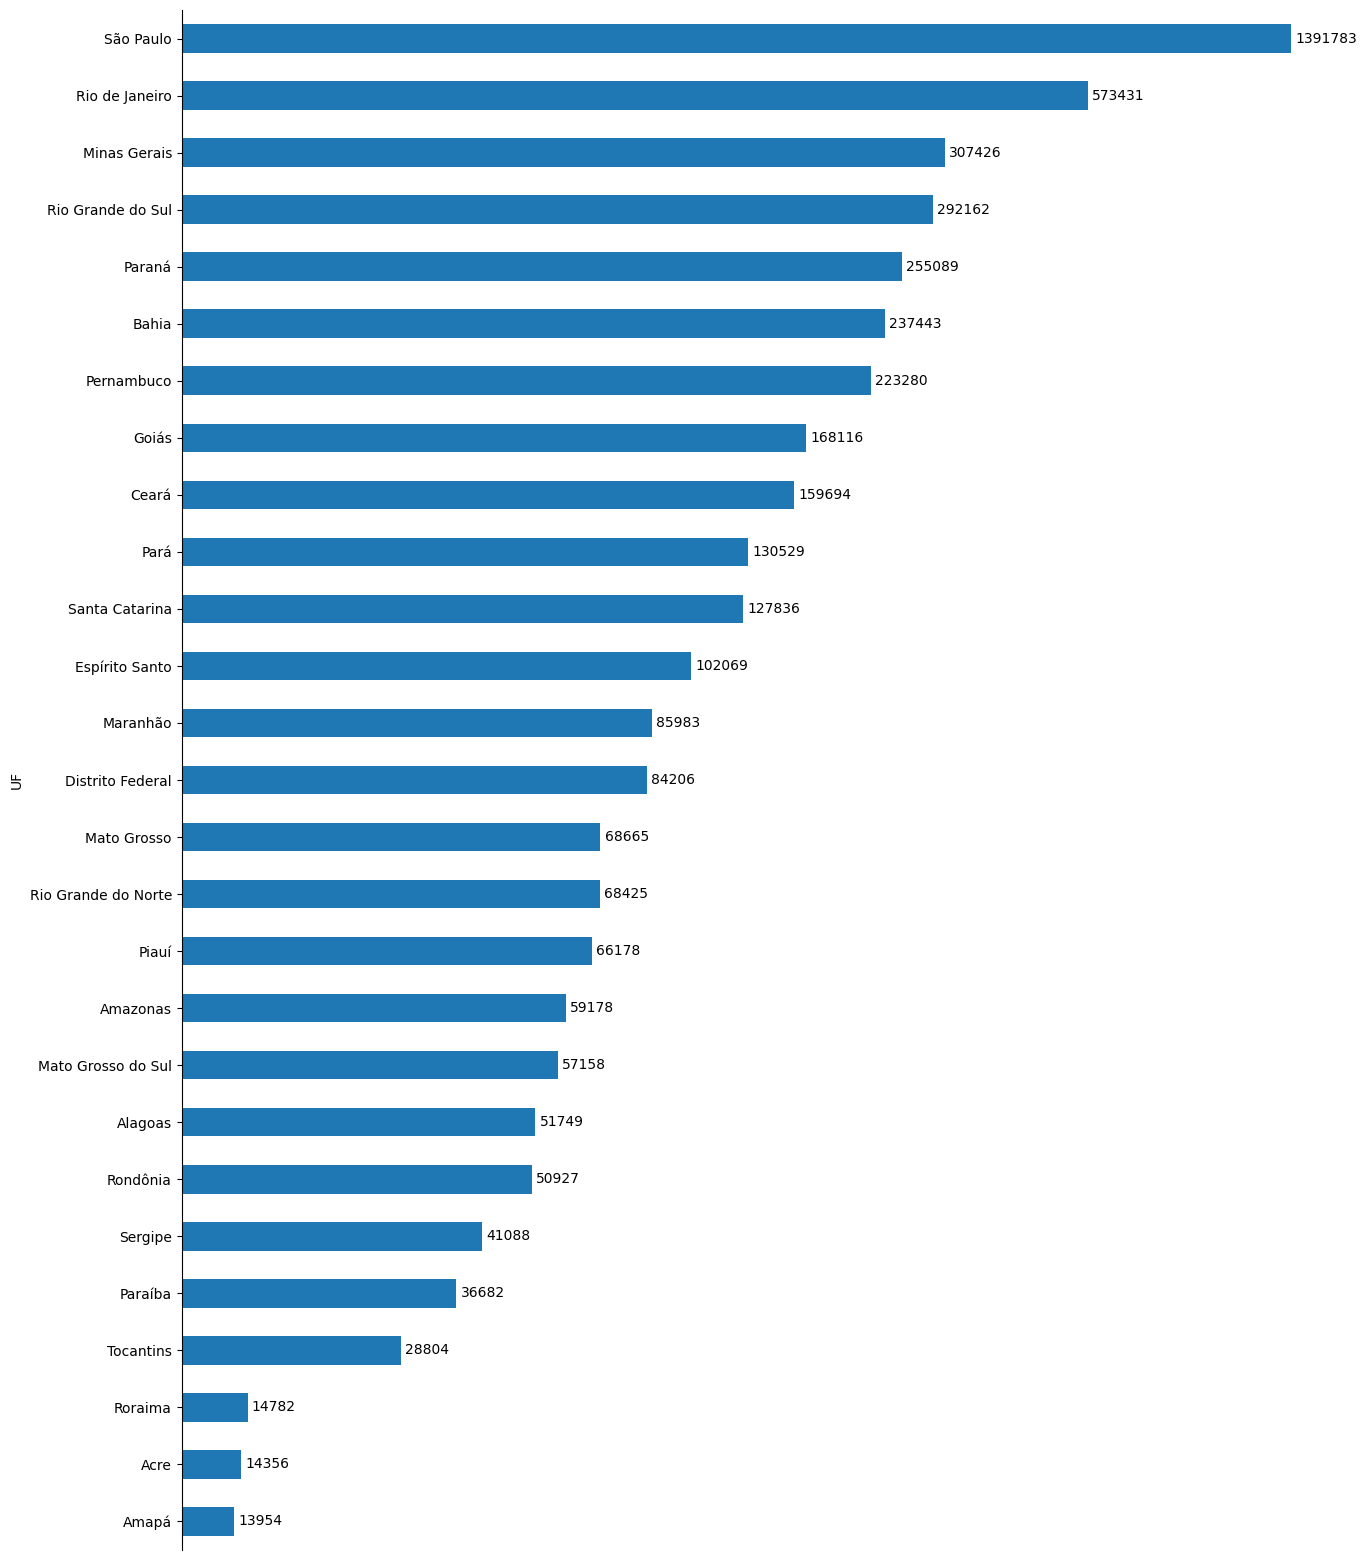

In [ ]:
data_uf = df_criminal.groupby('UF')['Ocorrências'].sum().sort_values(ascending=True)
ax = data_uf.plot(kind='barh', figsize=(15,20))
#ax.bar_label( data_uf,fmt="%.01f", size=10, label_type="edge")
ax.set_xscale('log')
ax.bar_label(ax.containers[0],padding=3, fmt = '%.0f')
ax.xaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.show()

In [ ]:
#criação do atributo tx_100mil
df_crimes_ano.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   UF           1938 non-null   object
 1   Tipo Crime   1938 non-null   object
 2   Ano          1938 non-null   int64 
 3   Ocorrências  1938 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 60.7+ KB


In [ ]:
base_pop_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   UF         216 non-null    object
 1   Ano        216 non-null    object
 2   População  216 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.2+ KB


In [ ]:
base_geral = df_crimes_ano.merge(base_pop_long,on=['UF'],how='inner')
base_geral

,UF,Tipo Crime,Ano_x,Ocorrências,Ano_y,População
0,Acre,Estupro,2015,42,2015,831665
1,Acre,Estupro,2015,42,2016,844137
2,Acre,Estupro,2015,42,2017,856457
3,Acre,Estupro,2015,42,2018,869265
4,Acre,Estupro,2015,42,2019,881935
...,...,...,...,...,...,...
15499,Tocantins,Tentativa de homicídio,2022,395,2018,1555229
15500,Tocantins,Tentativa de homicídio,2022,395,2019,1572866
15501,Tocantins,Tentativa de homicídio,2022,395,2020,1590248
15502,Tocantins,Tentativa de homicídio,2022,395,2021,1607363


##3.2 - Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [ ]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
sepal length (cm),5.843333
sepal width (cm),3.057333
petal length (cm),3.758000
petal width (cm),1.199333


In [ ]:
# Qual gráfico seria interessante usar pra mostrar a média?

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
sepal length (cm),0.828066
sepal width (cm),0.435866
petal length (cm),1.765298
petal width (cm),0.762238


In [ ]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?

##3.3 - Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *sepal length*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(df['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Frequência')
plt.show()

NameError: name 'df' is not defined

<Figure size 800x600 with 0 Axes>

O histograma mostra a distribuição do comprimento da sépala. A curva de densidade estimada (KDE) nos indica que a distribuição parece bimodal ou multimodal, indicando que as espécies podem ter comprimentos de sépalas diferentes.

### *sepal width*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

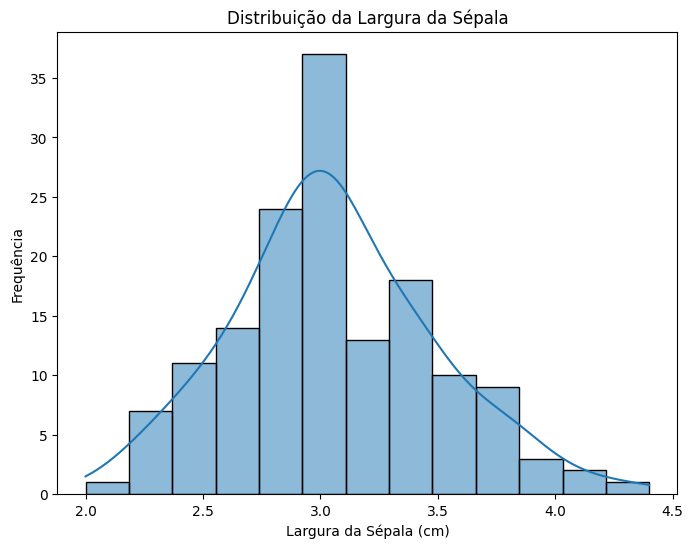

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(df['sepal width (cm)'], kde=True)
plt.title('Distribuição da Largura da Sépala')
plt.xlabel('Largura da Sépala (cm)')
plt.ylabel('Frequência')
plt.show()

Quais impressões você tem sobre a distribuição do atributo 'sepal width'?

##3.4 - Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
df.groupby('species').describe()

sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean       std  min  25%  50%  75%  max  
species                                                                
setosa                 50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor             50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica              50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

### *petal length* por Espécie


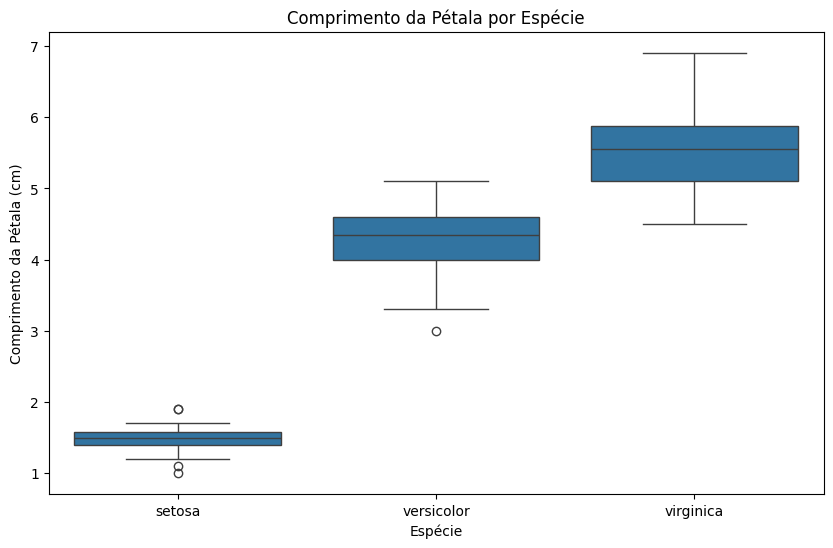

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Comprimento da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Comprimento da Pétala (cm)')
plt.show()

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

### *petal width* por Espécie

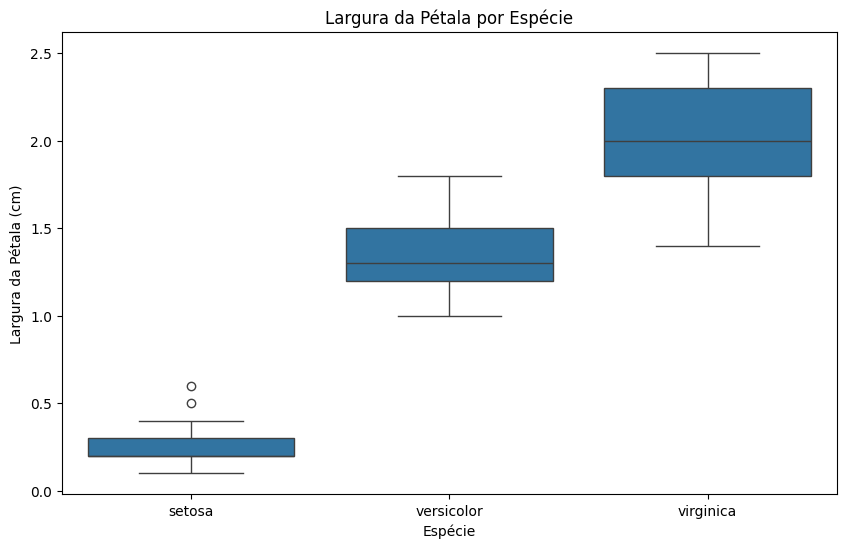

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal width (cm)', data=df)
plt.title('Largura da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Largura da Pétala (cm)')
plt.show()

Quais impressões o boxplot trouxe?

##3.5 - Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df.iloc[:, :4].corr()


Matriz de Correlação:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


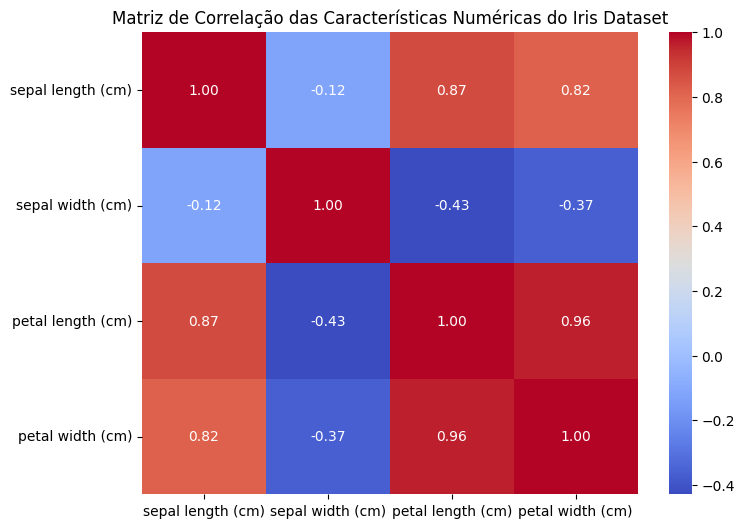

In [ ]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Iris Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

##3.6 - Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
df.isnull().sum()

Valores nulos no dataset Iris:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


#4 - Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Separar features (X) e target (y)
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (105, 4)
Dimensões de X_test: (45, 4)
Dimensões de y_train: (105,)
Dimensões de y_test: (45,)


##4.1 - Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.208333           0.327586          0.416667
1           0.527778          0.083333           0.586207          0.583333
2           0.222222          0.750000           0.068966          0.083333
3           0.694444          0.500000           0.827586          0.916667
4           0.388889          0.333333           0.517241          0.500000


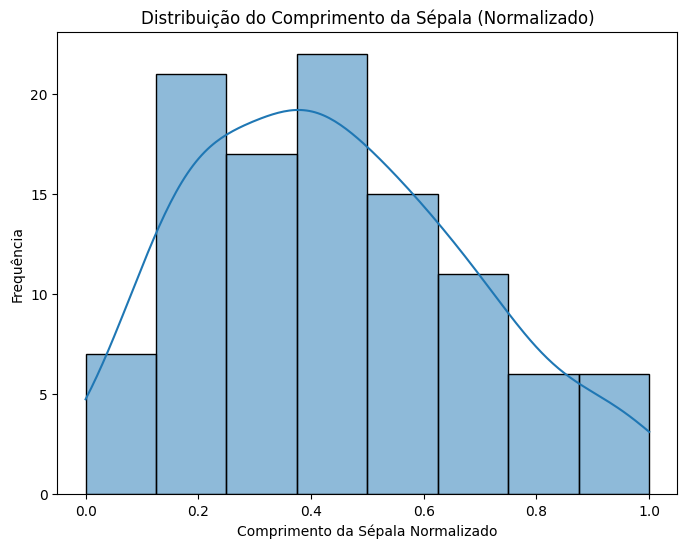

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Normalizado)')
plt.xlabel('Comprimento da Sépala Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

##4.2 - Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900459         -1.220248          -0.441986         -0.136610
1           0.380366         -1.879558           0.402829          0.380294
2          -0.900459          1.636764          -1.286801         -1.170419
3           1.078998          0.318143           1.191323          1.414103
4          -0.201827         -0.560937           0.177545          0.121842


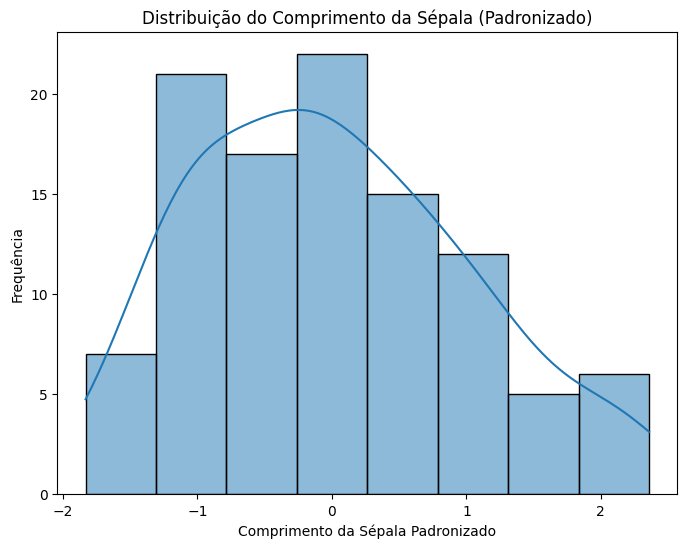

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Padronizado)')
plt.xlabel('Comprimento da Sépala Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

##4.3 - Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



#5 - Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



##5.1 - Hipótese 1

In [ ]:
# hipótese 1

##5.2 - Hipótese 2

In [ ]:
# hipótese 2

##5.3 - Hipótese 3

In [ ]:
# hipótese 3

#6 - Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.